Project Context
Consider a class of colonel blotto games with two battlefields and two generals, one defending general and one attacking general. Both generals have n troops and must decide how to allocate these troops between the two battlefields. For each battlefield, the defender wins if they have at least as many troops as the attacker (meaning they win in a tie) and the attacker wins if they have more troops than the defender. The total utility of the game is 1 if the defender defends both battlefields, 0 if they defend one of the battlefields, and -1 if they defend neither battlefield (this last option is not possible because the defender and attacker have the same number of troops). The defending general wants to maximize utility while the attacking general wants to minimize it, and they must commit to a pure or mixed strategy without knowing the strategy of the other general.
The defending troops will do whatever they are told. The attacking troops, however, receive utility m for obeying orders (as opposed to defecting) and are penalized utility p if they are captured during an attack. If X is the perceived mixed strategy of the attacking general and Y is the perceived mixed strategy of the defending general, the attacking troops will defect if the expected capture probability C(X, Y) <= 𝛳, where 𝛳 is equal to m/p. The defending general may manipulate their mixture Y in order to take advantage of this deterrence dynamic. The attacking general must be careful about their own mixed strategy in order to prevent their troops from defecting.
When ½ <= 𝛳 < (3[n//2]+1)/(4[n//2]+2), there do not exist Nash equilibrium values of X and Y. In other words, it is not clear what rational generals would do in this situation.
Using Robust Control
For our final project, we would like to formulate this as a control problem. We would like to define state dynamics for how the defending general and attacking troops behave, and optimize how the attacking general controls this situation. The inputs to the system will be the attack mixed strategy X and m, the utility paid to the attacking troops for not defecting. The goal will be for the attacking general to maximize the amount of utility they profit in the long run. For added complexity, we can say p is unknown and defined by some prior distribution.
The goal of this project is to find a reasonable way to define this problem in terms of robust control. Once we have defined a controller, we will observe how it performs in simulation against various defending general strategies, which could include security policies, best response tactics, or randomness.

Colonel Blotto Simulation

I want to be able to simulate a colonel blotto game with the ability to control/change lots of parameters and versions of it.
One version is where each iteration of the game both sides replenish their troop count at the start (for the attacking troops, conditioned on the perceived capture probability and m/p ratio), and the other has a sort of retaining mechanism and thus we have to worry about the number of troops being lost/captured per game. Another thing I want to (eventually) do is allow the troops that intend to attack the capacity to defect at multiple points throughout the process (eg whether or not to initially join, after deciding the next step mixture of troop distribution, sampling from the distribution...).
For every iteration, there will be a few parameters:
Nd - num defending troops (default 2)
Na - num attacking troops (default 2)
m - payment to troops (init to 1)
p - penaltiy for troops getting captured (init to 2)
a - memory of past games
c_0 - inital perceived capture probability (needs to be low enough for troops to join in the first place).

The process can look something like this:
C_t (perceived capture probabiliyt at time t) = a(c_(t-1)) = (1-a)(c (ie how many troops were captured last time))
For the one-shot game (not worrying about replenishing troops), troops decide whether or not to join the army (based on m/p ratio and perceive capture probability), and maybe can defect later on. When they choose not to join or defect, that gets applied to the memory as a no-capture game, improving odds of future troops joining.
The utitilty of the game is zero-sum, so the attacker is negative whatever the defender gets.

In [21]:
from enum import Enum
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [22]:
class Controller:
    def get_action(self, state):
        """
        Not sure how we'll be using this, but thought I'd throw it in.
        """
        raise NotImplementedError("Not yet implemented")


class ColonelBlottoEnv:
    def __init__(self, n_def=2, n_att=2, m=1.0, p=2.0, alpha=0.5, c_0=0.1, retain = False):
        self.n_def = n_def
        self.n_att = n_att
        self.m = m
        self.p = p
        self.alpha = alpha
        self.c_0 = c_0
        self.retain = retain

        self.c_t = self.c_0  # Perceived capture probability
        self.history = []

    def reset(self):
        self.c_t = self.c_0
        self.history = []
        return self._get_state()

    def copy(self):
        new_env = ColonelBlottoEnv(self.n_def, self.n_att, self.m, self.p, self.alpha, self.c_0, self.retain)
        new_env.history = copy.deepcopy(self.history)
        new_env.c_t = self.c_t
        return new_env

    def _get_state(self):
        return {
            'n_def': self.n_def,
            'n_att': self.n_att,
            'c_t': self.c_t,
            'm': self.m,
            'p': self.p
        }

    def step(self, action_att, action_def, m_override=None):
        """
        Executes one iteration of the game.
        action_att: Troops sent by attacker to Battlefield 1 (0 to n_att)
        action_def: Troops sent by defender to Battlefield 1 (0 to n_def)
        m_override: Optional new payment m for this step (Controller input)
        """
        current_m = m_override if m_override is not None else self.m
        theta = current_m / self.p
        defect = self.c_t > theta

        if defect:
            def_utility = 1
            att_utility = -1
            capture_rate = 0.0  # Counted as a no-capture game improving future odds

        else:
            # Simulate the battle
            att_1 = action_att
            att_2 = self.n_att - action_att

            def_1 = action_def
            def_2 = self.n_def - action_def

            def_wins_1 = def_1 >= att_1
            num_captures_1 = att_1 if def_wins_1 else -def_1
            def_wins_2 = def_2 >= att_2
            num_captures_2 = att_2 if def_wins_2 else -def_2

            total_captures = num_captures_1 + num_captures_2 #For retaining

            # Calculate Utilities
            if def_wins_1 and def_wins_2:
                def_utility = 1
            elif def_wins_1 or def_wins_2:
                def_utility = 0
            else:
                def_utility = -1 #Shouldn't ever happen, and if it does, that's a problem

            att_utility = -def_utility

            # Get capture rate
            captured_troops = 0
            if def_wins_1: captured_troops += att_1
            if def_wins_2: captured_troops += att_2
            capture_rate = captured_troops / self.n_att if self.n_att > 0 else 0

            # Simple retaining mechanism, happy to change it in the future
            if self.retain:
                self.n_def += total_captures
                self.n_att -= total_captures
                self.n_att += 0

        # Update perceived capture probability via exponential moving average
        self.c_t = self.alpha * self.c_t + (1 - self.alpha) * capture_rate

        step_info = {
            'defect': defect,
            'def_utility': def_utility,
            'att_utility': att_utility,
            'capture_rate': capture_rate,
            'new_c_t': self.c_t
        }
        self.history.append(step_info)

        return self._get_state(), att_utility, def_utility, step_info

In [23]:
# The different agents/heuristics will go here. i just put the most basic ones to start
class RandomAttacker(Controller):
    def get_action(self, state):
        return np.random.randint(0, state['n_att'] + 1)

class RandomDefender(Controller):
    def get_action(self, state):
        return np.random.randint(0, state['n_def'] + 1)

class EvenDefender(Controller):
    def get_action(self, state):
        return state['n_def'] // 2

# Not set up to handle retaining simulations
class MCAttacker(Controller):
    def __init__(self, is_static: bool=True):
        self.is_static = is_static
        self.best_amount = None
        self.mixture = 1
        self.simulation_env = ColonelBlottoEnv(0, 0, 0, 0, 0, 0, False)

    def get_action(self, state: dict[str, int|float]) -> int:
        """Gets the highest one-step utility decision for a non-retaining simulation

        Arguments:
            state {dict[str, int | float]} -- State

        Returns:
            int -- Move to make
        """
        if self.is_static and self.best_amount is not None:
            return self.best_amount

        self.simulation_env.n_def = state["n_def"]
        self.simulation_env.n_att = state["n_att"]
        self.simulation_env.m = state["m"]
        self.simulation_env.p = state["p"]
        self.simulation_env.alpha = 0.5
        self.simulation_env.c_0 = 0.1

        simulation_data: dict[int, list[int]] = {}
        # Loop through all possible attacker amounts and then check that amount against all the
        # possible defender amounts. Picks the one that gets the highest utility for all defender
        # strategies. It is worth noting that this really isn't a monte carlo simulation since there
        # isn't any randomization implemented here. It is just checking all possibilities since
        # there is a limited number of them
        for attacker_amount in range(state["n_att"]):
            if attacker_amount not in simulation_data:
                simulation_data[attacker_amount] = [0, 0]
            simulation_data[attacker_amount][0] += 1
            for defender_amount in range(state["n_def"]):
                _, reward_a, _, _ = self.simulation_env.step(attacker_amount, defender_amount)
                simulation_data[attacker_amount][1] += reward_a

        averaged_scores = [[amount, data[1] / data[0] if data[0] > 0 else -np.inf] for amount, data in simulation_data.items()]
        sorted_amounts = sorted(averaged_scores, key=lambda x: x[1], reverse=True)

        best_amount = sorted_amounts[0][0]

        if self.is_static:
            self.best_amount = best_amount

        return best_amount

class SimulationPlayerType(Enum):
    DEFENDER = 1
    ATTACKER = 2

def get_random_move(env: ColonelBlottoEnv, player_type: SimulationPlayerType) -> int:
    """Gets a random move for the given player type

    Arguments:
        env {ColonelBlottoEnv} -- Environment
        player_type {SimulationPlayerType} -- Player type

    Returns:
        int -- Move
    """
    return np.random.randint(0, get_num_troops(env, player_type) + 1)

def get_num_troops(env: ColonelBlottoEnv, player_type: SimulationPlayerType) -> int:
    """Returns the number of troops for the given player type

    Arguments:
        env {ColonelBlottoEnv} -- Environment
        player_type {SimulationPlayerType} -- Player type

    Returns:
        int -- Number of troops
    """
    return env.n_att if player_type is SimulationPlayerType.ATTACKER else env.n_def

class MCTSNode:
    def __init__(self, env: ColonelBlottoEnv, player_type: SimulationPlayerType, parent, c=np.sqrt(2), num_simulations=100):
        self.num_simulations = num_simulations
        self.env: ColonelBlottoEnv = env
        self.player_type: SimulationPlayerType = player_type
        self.other_player_type: SimulationPlayerType = SimulationPlayerType.ATTACKER if player_type is SimulationPlayerType.DEFENDER else SimulationPlayerType.DEFENDER
        self.parent: MCTSNode = parent
        self.num_troops = get_num_troops(env, self.player_type)
        self.terminal = self.num_troops == 0
        self.children = dict()
        for m in range(self.num_troops + 1):
            self.children[m] = None

        self.num_visits = 0
        self.total_utility = 0
        self.c = c

    def max_child(self) -> int:
        """Return the most visited child. This is used at the root node to make a final decision

        Returns:
            int -- Number of the most visited child (which corresponds to the action)
        """
        max_n = 0
        max_m = None

        for m in range(self.num_troops + 1):
            if self.children[m].num_visits > max_n:
                max_n = self.children[m].num_visits
                max_m = m
        return max_m

    def upper_bound(self, num_visits: int):
        #This function returns the UCB for this node
        #N is the number of samples for the parent node, to be used in UCB calculation
        bound = (self.total_utility / self.num_visits) + (self.c * np.sqrt(np.log(num_visits) / self.num_visits))
        return bound

    def make_move(self, env: ColonelBlottoEnv, cur_move: int, parent_move: int) -> int:
        """Makes a move in the game from the current node

        Arguments:
            env {ColonelBlottoEnv} -- Environment to make the move in
            cur_move {int} -- Current nodes decided move
            parent_move {int} -- Parent nodes decided move

        Returns:
            int -- Reward for the current node
        """
        if self.player_type is SimulationPlayerType.ATTACKER:
            a_move, d_move = cur_move, parent_move
        else:
            a_move, d_move = parent_move, cur_move
        _, reward_a, reward_d, _ = env.step(a_move, d_move)
        return reward_a if self.player_type is SimulationPlayerType.ATTACKER else reward_d

    def select(self):
        """ Recursively selects a node to simulate from based on a couple characteristics like how often
        the node has been visited and the utility that has been produced through that node

        Returns:
            MCTSNode -- Selected node
        """
        if self.terminal:
            #If this is a terminal node, then return it
            return self

        max_ub = -np.inf
        max_child = None

        #For all of the children of this node
        for move in range(self.num_troops + 1):
            if self.children[move] is None:
                new_env = self.env.copy()
                # TODO Instead of doing it this way, have it find the move from the enemy that is
                # worst for this move maybe? that will always rig it though since defender has the
                # advantage. Having it rely so heavily on luck with the first one isn't optimal.
                # Maybe instead grab the enemy move that is in the median of utility?
                utility = self.make_move(new_env, move, get_random_move(new_env, self.other_player_type))

                self.children[move] = MCTSNode(new_env, self.other_player_type, self, self.c, self.num_simulations) #Create the child node
                score = utility * self.num_simulations
                self.children[move].total_utility += score
                return self.children[move] #Return it

            #Child already exists, get it's UCB value
            current_ub = self.children[move].upper_bound(self.num_visits)

            #Compare to previous best UCB
            if current_ub > max_ub:
                max_ub = current_ub
                max_child = move

        #Recursively return the select result for the best child
        return self.children[max_child].select()

    def simulate(self):
        """Simulates random games and backpropogates the utility from those games
        """
        new_env = self.env.copy()
        utility = 0
        orig_num_troops = get_num_troops(new_env, self.player_type)
        orig_other_num_troops = get_num_troops(new_env, self.other_player_type)
        n_att = new_env.n_att
        n_def = new_env.n_def

        for _ in range(self.num_simulations):
            num_troops = orig_num_troops
            other_num_troops = orig_other_num_troops
            new_env.n_att = n_att
            new_env.n_def = n_def
            # Requires that at least one run gets made for the sake of utility
            i = 0
            while (num_troops != 0 and other_num_troops != 0) or i == 0:
                move = np.random.randint(0, num_troops + 1)
                other_move = np.random.randint(0, other_num_troops + 1)
                # Total utility is from the perspective of the parent node so it is subtracted
                utility -= self.make_move(new_env, move, other_move)
                num_troops = get_num_troops(new_env, self.player_type)
                other_num_troops = get_num_troops(new_env, self.other_player_type)
                i += 1

        self.total_utility += utility
        self.num_visits += 1
        self.parent.back(-utility)

    def back(self, score):
        """ Backpropagate utility up the tree
        """
        self.num_visits += 1
        self.total_utility += score
        if self.parent is not None:
            self.parent.back(-score)

class MCTSController(Controller):
    def __init__(self, player_type: SimulationPlayerType = SimulationPlayerType.ATTACKER, depth: int = 100, num_simulations_per_depth: int = 5):
        self.mixture = 1
        self.depth = depth
        self.num_simulations_per_depth = num_simulations_per_depth
        self.player_type = player_type

        self.simulation_env = ColonelBlottoEnv(0, 0, 0, 0, 0, 0, True)

    def get_action(self, state: dict[str, int|float]) -> int:
        """Gets the action for the monte carlo tree search controller

        Arguments:
            state {dict[str, int | float]} -- State dictionary

        Returns:
            int -- Action
        """
        self.simulation_env.n_def = state["n_def"]
        self.simulation_env.n_att = state["n_att"]
        self.simulation_env.m = state["m"]
        self.simulation_env.p = state["p"]
        self.simulation_env.alpha = 0.5
        self.simulation_env.c_0 = 0.1

        if get_num_troops(self.simulation_env, self.player_type) == 0:
            return 0
        #Make the MCTS root node from the current env state
        root = MCTSNode(self.simulation_env, self.player_type, None, np.sqrt(2), self.num_simulations_per_depth)
        for _ in range(self.depth):

            #Select + Expand
            cur_node = root.select()

            #Simulate + backpropate
            cur_node.simulate()

        return root.max_child()

class EthanRetainingHeuristicAttacker(Controller):
    def get_action(self, state: dict[str, int|float]) -> int:
        """Gets an action for the attacker when it has retaining troops. It will prioritize winning
        troops and then start distributing troops when it is a guaranteed win

        Arguments:
            state {dict[str, int | float]} -- State dictionary

        Returns:
            int -- Action to make
        """
        return np.random.choice([0, state["n_att"]]) if state["n_att"] <= state["n_def"] * 2 else state["n_att"] // 2

In [24]:
# Parameters to mess with/tune
# Observable
n_def = 10
n_att = 10
m = 1.0

# Varying levels of observable
p = 2.0
c_0 = 0.1

# not directly observable
alpha = 0.5

In [25]:
# Run simulation to gather data
sim_iters = 25
num_steps = 100

all_sims = {}
for i in range(sim_iters):
    env = ColonelBlottoEnv(n_def, n_att, m, p, alpha, c_0, True) # False means it's one shot, True has the retaining feature
    attacker = MCTSController(SimulationPlayerType.ATTACKER, 100, 5)
    # attacker = EthanRetainingHeuristicAttacker()
    defender = RandomDefender()
    # defender = MCTSController(SimulationPlayerType.DEFENDER, 100, 5)
    state = env.reset()

    sim_data = []

    for t in range(num_steps):
        act_a = attacker.get_action(state)
        act_d = defender.get_action(state)

        next_state, reward_a, reward_d, info = env.step(act_a, act_d)

        sim_data.append({
            'step': t,
            'act_a': act_a,
            'act_d': act_d,
            'reward_a': reward_a,
            'reward_d': reward_d,
            'capture_rate': info['capture_rate'],
            'captured_troops': info['capture_rate'] * state['n_att'],
            'n_att': state['n_att'],
            'n_def': state['n_def']
        })

        state = next_state

    all_sims[i] = sim_data

In [26]:
# Add some features for data viz
dfs = []
for sim_id, sim_data in all_sims.items():
    df = pd.DataFrame(sim_data)
    df['sim_id'] = sim_id
    df['avg_reward_a'] = df['reward_a'].expanding().mean()
    df['avg_reward_d'] = df['reward_d'].expanding().mean()
    df['avg_captured_troops'] = df['captured_troops'].expanding().mean()
    dfs.append(df)

# Combine all simulations into one dataframe
df_all = pd.concat(dfs, ignore_index=True)

# Calculate the mean across all simulations per step for plotting
df_mean = df_all.groupby('step').mean().reset_index()

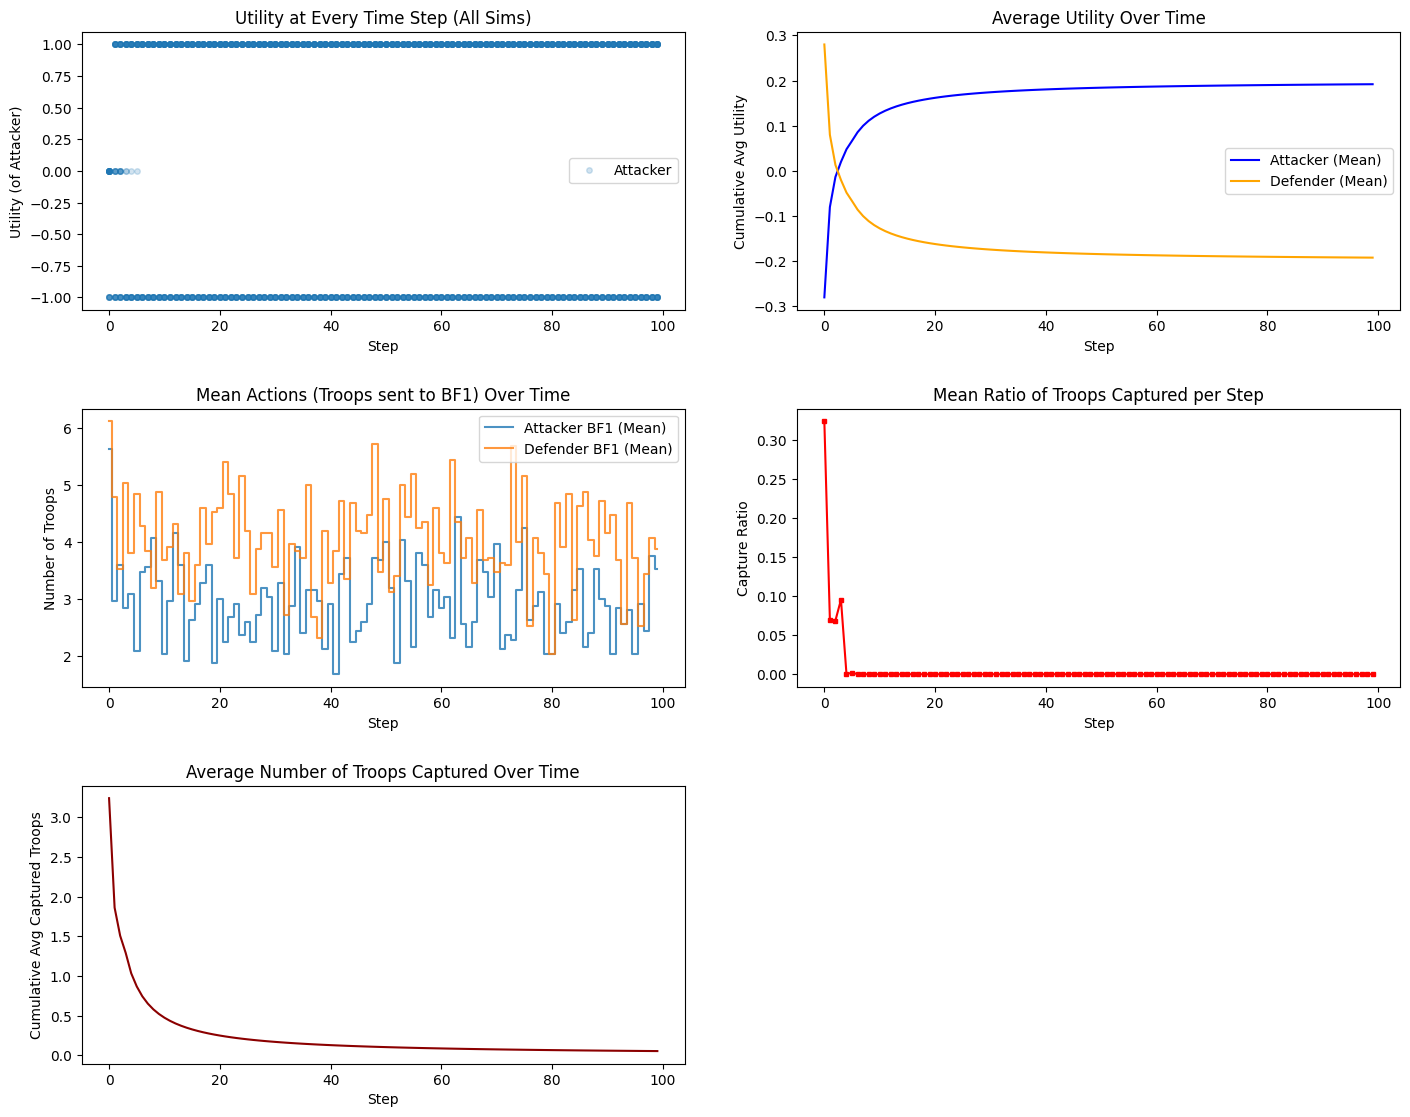

In [27]:
#Plot a bunch of stuff
# Create a faceted figure (3 rows, 2 columns)
fig, axs = plt.subplots(3, 2, figsize=(15, 12))
fig.tight_layout(pad=5.0)

# 1. Utility at every time step (scatter across all sims to see distribution)
axs[0, 0].plot(df_all['step'], df_all['reward_a'], label='Attacker', alpha=0.2, marker='o', markersize=4, linestyle='None')
axs[0, 0].set_title('Utility at Every Time Step (All Sims)')
axs[0, 0].set_xlabel('Step')
axs[0, 0].set_ylabel('Utility (of Attacker)')
axs[0, 0].legend()

# 2. Avg utility over time (mean across sims)
axs[0, 1].plot(df_mean['step'], df_mean['avg_reward_a'], label='Attacker (Mean)', color='blue')
axs[0, 1].plot(df_mean['step'], df_mean['avg_reward_d'], label='Defender (Mean)', color='orange')
axs[0, 1].set_title('Average Utility Over Time')
axs[0, 1].set_xlabel('Step')
axs[0, 1].set_ylabel('Cumulative Avg Utility')
axs[0, 1].legend()

# 3. Actions over time (mean across sims)
axs[1, 0].step(df_mean['step'], df_mean['act_a'], label='Attacker BF1 (Mean)', alpha=0.8, where='mid')
axs[1, 0].step(df_mean['step'], df_mean['act_d'], label='Defender BF1 (Mean)', alpha=0.8, where='mid')
axs[1, 0].set_title('Mean Actions (Troops sent to BF1) Over Time')
axs[1, 0].set_xlabel('Step')
axs[1, 0].set_ylabel('Number of Troops')
axs[1, 0].legend()

# 4. Ratio of troops captured at every timestep (mean across sims)
axs[1, 1].plot(df_mean['step'], df_mean['capture_rate'], color='red', marker='s', markersize=3, linestyle='-')
axs[1, 1].set_title('Mean Ratio of Troops Captured per Step')
axs[1, 1].set_xlabel('Step')
axs[1, 1].set_ylabel('Capture Ratio')

# 5. Avg number of troops captured (mean across sims)
axs[2, 0].plot(df_mean['step'], df_mean['avg_captured_troops'], color='darkred')
axs[2, 0].set_title('Average Number of Troops Captured Over Time')
axs[2, 0].set_xlabel('Step')
axs[2, 0].set_ylabel('Cumulative Avg Captured Troops')

# Hide the empty 6th subplot
axs[2, 1].axis('off')

plt.show()

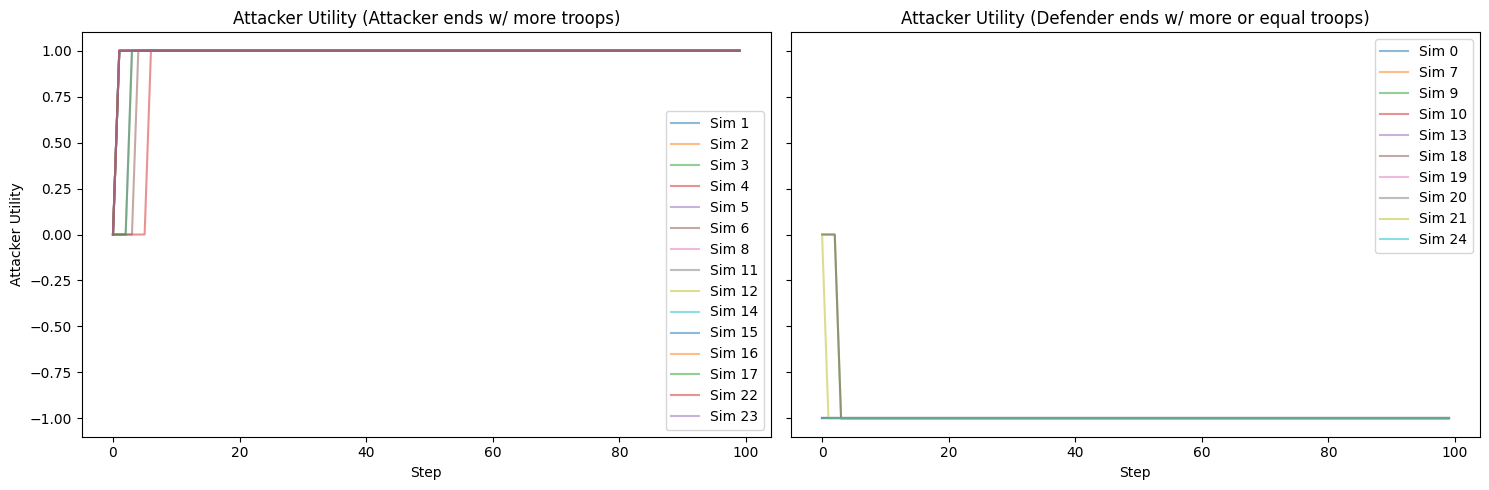

In [28]:
# Re-aggregate df_all just in case it wasn't re-run after adding n_att/n_def
dfs = []
for sim_id, sim_data in all_sims.items():
    df = pd.DataFrame(sim_data)
    df['sim_id'] = sim_id
    dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)

# Find final state for each simulation
final_states = df_all.groupby('sim_id').last()[['n_att', 'n_def']]

# Split simulation IDs based on who has more troops at the end
att_more_troops_sims = final_states[final_states['n_att'] > final_states['n_def']].index
def_more_troops_sims = final_states[final_states['n_def'] >= final_states['n_att']].index

# Create faceted figure
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Plot for simulations where Attackers have more troops
for sim_id in att_more_troops_sims:
    sim_df = df_all[df_all['sim_id'] == sim_id]
    axs[0].plot(sim_df['step'], sim_df['reward_a'], alpha=0.5, label=f'Sim {sim_id}')

axs[0].set_title('Attacker Utility (Attacker ends w/ more troops)')
axs[0].set_xlabel('Step')
axs[0].set_ylabel('Attacker Utility')
if len(att_more_troops_sims) > 0:
    axs[0].legend()

# Plot for simulations where Defenders have more troops (or tied)
for sim_id in def_more_troops_sims:
    sim_df = df_all[df_all['sim_id'] == sim_id]
    axs[1].plot(sim_df['step'], sim_df['reward_a'], alpha=0.5, label=f'Sim {sim_id}')

axs[1].set_title('Attacker Utility (Defender ends w/ more or equal troops)')
axs[1].set_xlabel('Step')
if len(def_more_troops_sims) > 0:
    axs[1].legend()

plt.tight_layout()
plt.show()